In [5]:
import torch
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Добавляем корень проекта в путь
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from osc_tools.ml.models import ConvKAN
from osc_tools.visualization.kan_plot import plot_kan_activation, plot_kan_layer_grid
from osc_tools.ml.config import ModelConfig

EXPERIMENTS_DIR = ROOT_DIR / 'experiments' / 'kan_activations'
print(f"Experiments Dir: {EXPERIMENTS_DIR}")

Experiments Dir: D:\Программирование\Fork\Scientific_research_osc_ML\experiments\kan_activations


In [2]:
def load_model(activation_name, num_classes=89, in_channels=12):
    model_path = EXPERIMENTS_DIR / f"ConvKAN_{activation_name}.pt"
    if not model_path.exists():
        print(f"Model not found: {model_path}")
        return None
    
    # Параметры должны совпадать с теми, что были при обучении
    # В run_kan_activations.py: base_filters=8, grid_size=5
    params = {
        "in_channels": in_channels,
        "num_classes": num_classes,
        "base_filters": 8,
        "grid_size": 5,
        "base_activation": getattr(torch.nn, activation_name) if hasattr(torch.nn, activation_name) else torch.nn.SiLU
    }
    
    model = ConvKAN(**params)
    state_dict = torch.load(model_path, map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [3]:
# Загрузка модели с SiLU (как основной)
model_silu = load_model("SiLU")

## Визуализация первого слоя (Convolutional KAN Layer)

ConvKAN состоит из сверточных слоев, где ядро свертки параметризуется сплайнами. 
В `ConvKAN` первый слой это `KANConv1d`. Он оборачивает `KANLinear`, который принимает на вход развернутые патчи (unfolded patches).

Размерность входа `KANLinear` в первом слое: `in_channels * kernel_size`.
Размерность выхода: `out_channels` (количество фильтров).

Мы можем визуализировать функции активации для каждого "веса" в ядре свертки.

Input Features (InChannels * KernelSize): 36
Output Features (Filters): 8
Визуализация функций активации для первого фильтра...


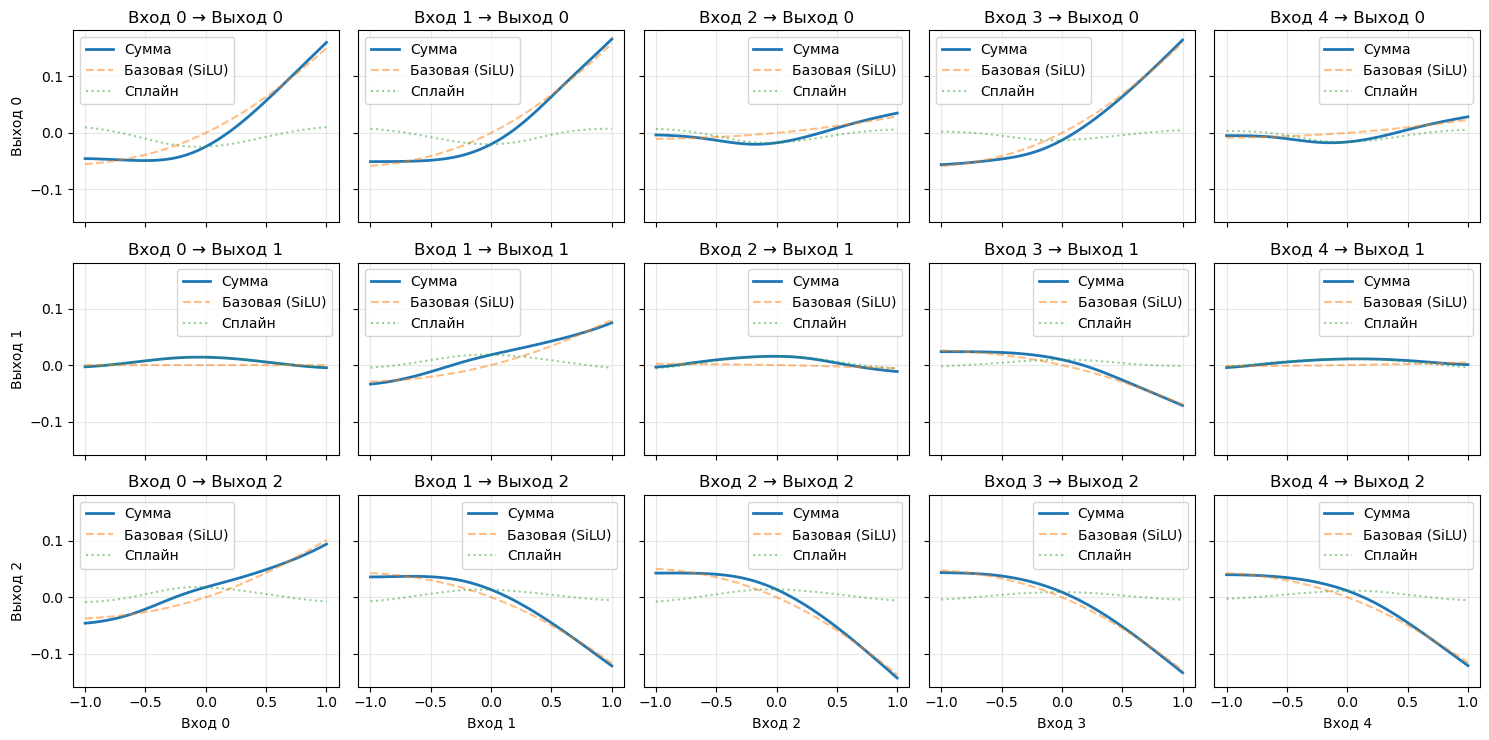

График сохранен в reports/figures/kan_activations_sample.png


In [6]:
if model_silu:
    # Получаем первый слой KANConv1d
    conv_layer = model_silu.features[0]
    # Получаем внутренний KANLinear
    kan_linear = conv_layer.kan_layer
    
    print(f"Input Features (InChannels * KernelSize): {kan_linear.in_features}")
    print(f"Output Features (Filters): {kan_linear.out_features}")
    
    # Визуализируем функции активации для первого фильтра (Output 0)
    # и первых 5 входов (соответствуют первым 5 каналам/позициям ядра)
    print("Визуализация функций активации для первого фильтра...")
    plot_kan_layer_grid(kan_linear, max_inputs=5, max_outputs=3)
    
    # Сохраним график
    plt.savefig(EXPERIMENTS_DIR.parent.parent / 'reports' / 'figures' / 'kan_activations_sample.png')
    plt.close()
    print("График сохранен в reports/figures/kan_activations_sample.png")

## Анализ важности признаков (Feature Importance)

В KAN важность связи можно оценить как L1-норму функции активации $\phi(x)$ на диапазоне входных значений.
Для сверточного слоя это позволяет понять, какие входные каналы и какие временные задержки (в пределах ядра) наиболее важны для формирования признаков.

Мы рассчитаем матрицу важности размером `(OutChannels, InChannels, KernelSize)`.

Расчет важности признаков...
Importance Matrix Shape: torch.Size([8, 36])


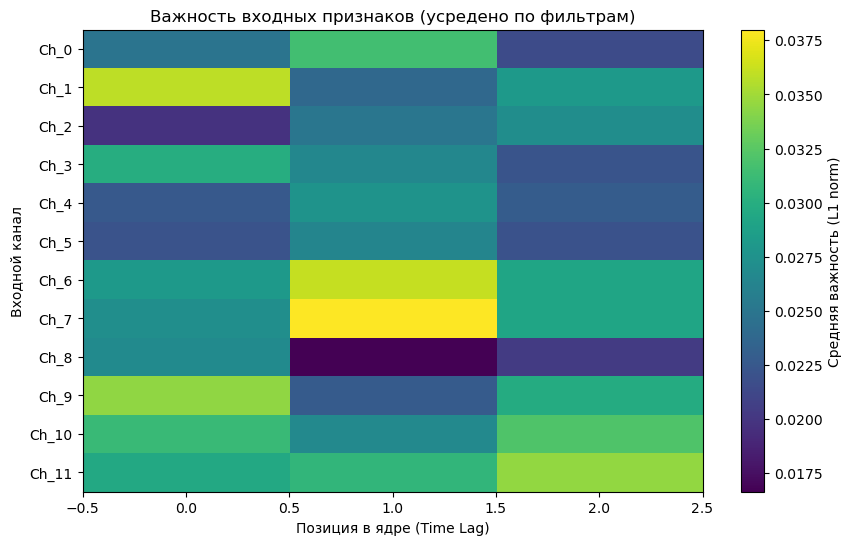

График важности сохранен.


In [8]:
import torch.nn.functional as F

def calculate_kan_importance(layer, x_range=(-1, 1), num_points=100):
    """
    Вычисляет важность (L1-норму) для каждой функции активации в слое.
    Returns:
        importance_matrix: (OutFeatures, InFeatures)
    """
    device = layer.base_weight.device
    x = torch.linspace(x_range[0], x_range[1], num_points).to(device)
    
    # (Batch, InFeatures) -> (num_points, InFeatures)
    # Мы хотим прогнать x через каждую функцию активации.
    # Но функции зависят от входа.
    # Сделаем это эффективно:
    # Для каждого входа j, мы подаем вектор x.
    
    # KANLinear.forward делает: base_output + spline_output
    # Нам нужно значение функции |phi_ij(x)|
    
    # Base part: w_b * SiLU(x)
    # Spline part: spline(x)
    
    # Рассчитаем сплайны для всех x сразу
    # layer.b_splines принимает (Batch, InFeatures)
    # Создадим батч, где каждая строка это одно и то же значение x для всех фичей?
    # Нет, нам нужно проинтегрировать по x.
    
    # Простой способ: усреднить абсолютные значения выхода для равномерного распределения x
    
    # Создаем вход (num_points, InFeatures), где в каждой колонке значения от -1 до 1
    # Но b_splines работает независимо по каналам, так что можно подать одинаковые x во все каналы
    batch_x = x.unsqueeze(1).expand(num_points, layer.in_features) # (num_points, InFeatures)
    
    # 1. Base output
    # base_activation(batch_x) * base_weight
    # base_weight: (Out, In)
    # base_out = F.linear(layer.base_activation(batch_x), layer.base_weight) # (num_points, Out)
    # Но это сумма по входам. Нам нужно отдельно для каждого входа.
    
    # Давайте считать по-другому.
    # Importance score = mean(|phi(x)|) over x
    
    scores = torch.zeros(layer.out_features, layer.in_features).to(device)
    
    # Это может быть медленно для больших слоев, но для первого слоя ОК
    # Оптимизация:
    # phi_ij(x) = w_b_ij * act(x) + sum(c_ijk * B_k(x)) * scale_ij
    
    # Precompute bases for x: (num_points, In, Grid+Order)
    bases = layer.b_splines(batch_x) 
    
    for out_i in range(layer.out_features):
        for in_j in range(layer.in_features):
            # Base
            y_base = layer.base_weight[out_i, in_j] * layer.base_activation(x)
            
            # Spline
            # bases[:, in_j, :] shape (num_points, Grid+Order)
            # spline_weight[out_i, in_j, :] shape (Grid+Order)
            y_spline = torch.matmul(bases[:, in_j, :], layer.spline_weight[out_i, in_j, :])
            
            if layer.enable_standalone_scale_spline:
                y_spline = y_spline * layer.spline_scaler[out_i, in_j]
                
            y_total = y_base + y_spline
            scores[out_i, in_j] = torch.mean(torch.abs(y_total))
            
    return scores

if model_silu:
    print("Расчет важности признаков...")
    importance = calculate_kan_importance(kan_linear)
    print(f"Importance Matrix Shape: {importance.shape}")
    
    # Reshape для Conv1d: (Out, InChannels, Kernel)
    out_channels = kan_linear.out_features
    in_channels_kernel = kan_linear.in_features
    kernel_size = conv_layer.kernel_size
    in_channels = in_channels_kernel // kernel_size
    
    importance_reshaped = importance.reshape(out_channels, in_channels, kernel_size)
    
    # Усредним по фильтрам (OutChannels), чтобы понять глобальную важность входов
    # (InChannels, Kernel)
    global_importance = importance_reshaped.mean(dim=0).detach().cpu().numpy()
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.imshow(global_importance, aspect='auto', cmap='viridis')
    plt.colorbar(label='Средняя важность (L1 norm)')
    plt.xlabel('Позиция в ядре (Time Lag)')
    plt.ylabel('Входной канал')
    plt.title('Важность входных признаков (усредено по фильтрам)')
    
    # Подписи каналов (если есть список имен)
    # В dataset.py или constants.py могут быть имена
    # Предположим стандартные 12 каналов
    channel_names = [f"Ch_{i}" for i in range(in_channels)]
    plt.yticks(range(in_channels), channel_names)
    
    plt.savefig(EXPERIMENTS_DIR.parent.parent / 'reports' / 'figures' / 'kan_feature_importance.png')
    plt.show()
    print("График важности сохранен.")